In [26]:
# load Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sea

sea.set(style="whitegrid")

In [27]:
# Load the dataset
df = sea.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [28]:
# Number of rows and columns in dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 891
Columns: 15


In [29]:
# Names of the columns present in the dataset
print("Columns in dataset:")
print(df.columns)

Columns in dataset:
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [30]:
# Detailed information or Physical View of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [31]:
# Missing values count
print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [32]:
# % of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
sex             0.000000
pclass          0.000000
survived        0.000000
fare            0.000000
parch           0.000000
sibsp           0.000000
class           0.000000
adult_male      0.000000
who             0.000000
alive           0.000000
alone           0.000000
dtype: float64

In [33]:
# Count of duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 107


In [34]:
# Basic Statistical Information
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [35]:
# Handling the missing data
df2 = df.copy()

# lets replace missing age values with the median
df2["age"] = df2["age"].fillna(df2["age"].median())

# Categorical data, replacing with the mode if not available
df2["embarked"] = df2["embarked"].fillna(df2["embarked"].mode()[0])

# more than 75% data is missing, thus lets drop the column
df2.drop(columns=["deck"], inplace=True)

df2.isnull().sum()


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [36]:
# Survival Count (0 -> Not Survived, 1 -> Survived)
df2["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

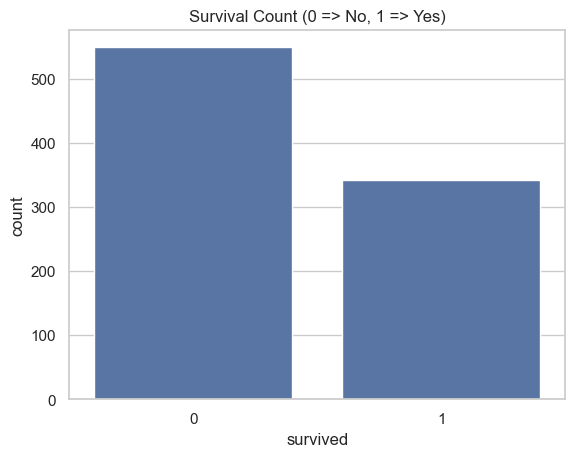

In [37]:
# Plotting the survival data
sea.countplot(x="survived", data=df2)
plt.title("Survival Count (0 => No, 1 => Yes)")
plt.show()

In [38]:
# The number of male or female passengers
df2["sex"].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

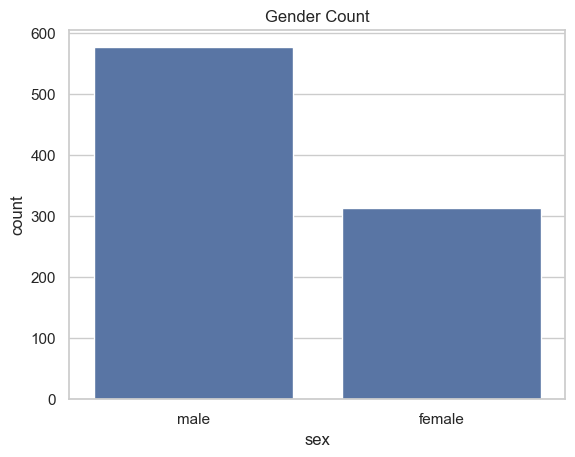

In [39]:
# The count presented on a countplot
sea.countplot(x="sex", data=df2)
plt.title("Gender Count")
plt.show()

In [41]:
# Seating class of passengers
df2["class"].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

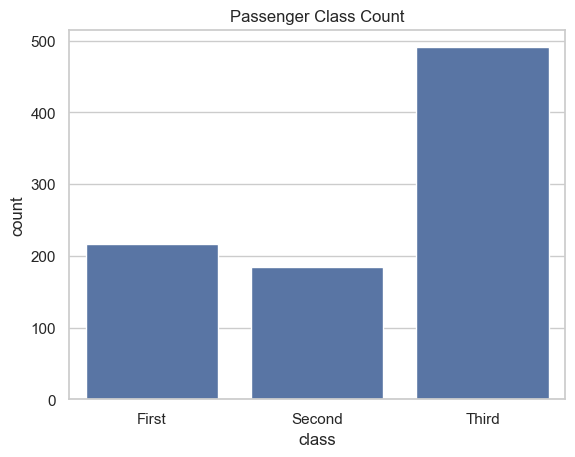

In [42]:
# Count of passengers in each class
sea.countplot(x="class", data=df2)
plt.title("Passenger Class Count")
plt.show()

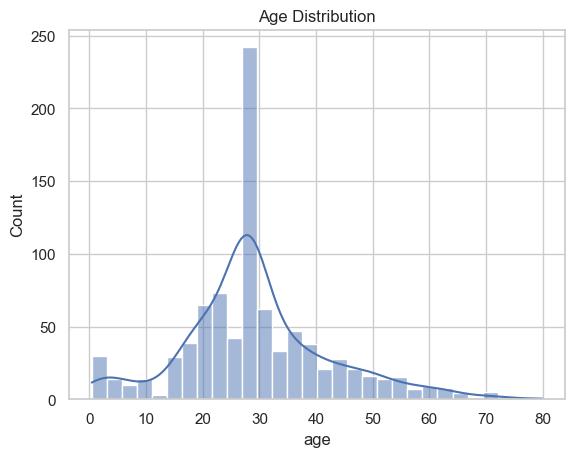

In [43]:
# Age Distribution Graph
sea.histplot(df2["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

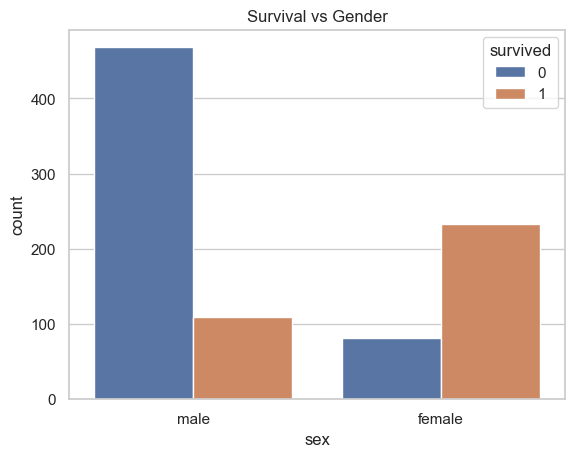

In [47]:
# Survival count with respect to sex
sea.countplot(x="sex", hue="survived", data=df2)
plt.title("Survival vs Gender")
plt.show()

In [48]:
# The Summary of the analysis
print("Final EDA Summary")
print("-------------------------")

total = len(df2)
survival_rate = df2["survived"].mean() * 100

print("Total passengers:", total)
print(f"Overall Survival Rate: {survival_rate:.2f}%")

print("\nSurvival Rate by Gender:")
print(df2.groupby("sex")["survived"].mean() * 100)

print("\nSurvival Rate by Class:")
print(df2.groupby("class")["survived"].mean() * 100)

Final EDA Summary
-------------------------
Total passengers: 891
Overall Survival Rate: 38.38%

Survival Rate by Gender:
sex
female    74.203822
male      18.890815
Name: survived, dtype: float64

Survival Rate by Class:
class
First     62.962963
Second    47.282609
Third     24.236253
Name: survived, dtype: float64


C:\Users\vedan\AppData\Local\Temp\ipykernel_26904\3758109091.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df2.groupby("class")["survived"].mean() * 100)
